In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df = pd.read_csv("task1_dataset.csv")
df.head()

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
1,2020-01-02,20,47161.859481,950897.454063,716.561294,33,5.951086e+05,Bangalore,Student,Home,154516.648673
2,2020-01-03,46,55234.345094,NaN,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,2020-01-04,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,2020-01-05,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929


In [3]:
df.isnull().sum()

date                 0
age                  0
income              80
loan_amount         80
credit_score        80
num_transactions     0
annual_spend        80
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [5]:
df.describe()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target
count,2000.000000,1920.000000,1.920000e+03,1920.000000,2000.00000,1.920000e+03,2000.000000
mean,43.569500,64111.180976,3.135794e+05,649.451886,30.13600,1.081605e+06,246455.466965
std,14.892786,35334.616365,1.415505e+05,80.483534,5.24006,7.028877e+05,66306.121409
min,18.000000,-5135.359342,-2.336766e+04,373.096400,14.00000,-1.461650e+05,13300.170171
25%,31.000000,46943.316170,2.337310e+05,594.475126,27.00000,7.887255e+05,201830.604797
50%,43.000000,60602.715999,3.041103e+05,649.578439,30.00000,1.004297e+06,245424.498558
75%,56.000000,75294.080356,3.722464e+05,703.239833,33.00000,1.214651e+06,292110.550126
max,69.000000,426093.266439,1.525158e+06,919.903709,52.00000,7.541094e+06,478502.472525


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              2000 non-null   object 
 1   age               2000 non-null   int64  
 2   income            1920 non-null   float64
 3   loan_amount       1920 non-null   float64
 4   credit_score      1920 non-null   float64
 5   num_transactions  2000 non-null   int64  
 6   annual_spend      1920 non-null   float64
 7   city              2000 non-null   object 
 8   employment_type   2000 non-null   object 
 9   loan_type         2000 non-null   object 
 10  target            2000 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


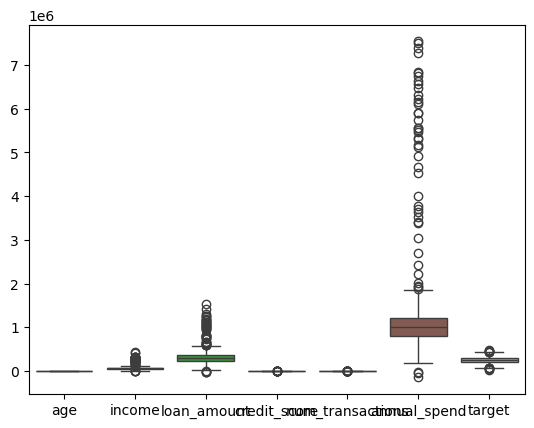

In [7]:
#check for outliers
sns.boxplot(data=df)
plt.show()

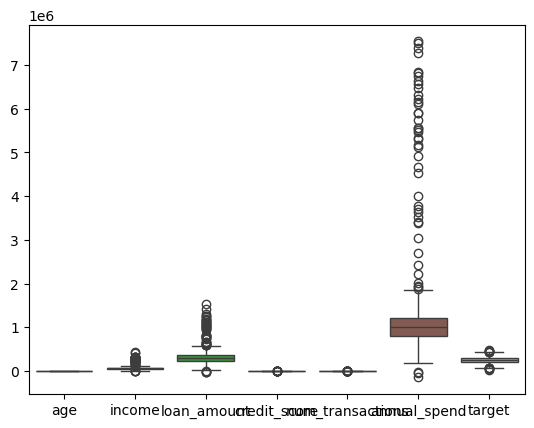

In [8]:
#check for outliers
sns.boxplot(data=df)
plt.show()

In [9]:
#check for missing values
df.isnull().sum()
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
#convert the categorical variable into numerical variable

df = pd.get_dummies(df, drop_first=True)

In [12]:
print(df.columns)

Index(['age', 'income', 'loan_amount', 'credit_score', 'num_transactions',
       'annual_spend', 'target', 'date_2020-01-02', 'date_2020-01-03',
       'date_2020-01-04',
       ...
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Mumbai',
       'employment_type_Self-Employed', 'employment_type_Student',
       'employment_type_Unemployed', 'loan_type_Education', 'loan_type_Home',
       'loan_type_Personal'],
      dtype='object', length=2016)


In [15]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [18]:
#handled missing values by filling them with median values 
#find the median values of the credit score and income columns and loan amount column 

median_credit_score = df['credit_score'].median()
median_income = df['income'].median()
median_loan_amount = df['loan_amount'].median()
median_loan_amount = df['annual_spend'].median()
#fill the missing values with median values
df['credit_score'].fillna(median_credit_score, inplace=True)
df['income'].fillna(median_income, inplace=True)
df['loan_amount'].fillna(median_loan_amount, inplace=True)
df['annual_spend'].fillna(median_loan_amount, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_28432\2861508817.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_score'].fillna(median_credit_score, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_28432\2861508817.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [19]:
#ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [21]:
#handled the outliers length of each column
Q1_credit_score = df['credit_score'].quantile(0.25)
Q3_credit_score = df['credit_score'].quantile(0.75)
IQR_credit_score = Q3_credit_score - Q1_credit_score
lower_bound_credit_score = Q1_credit_score - 1.5 * IQR_credit_score
upper_bound_credit_score = Q3_credit_score + 1.5 * IQR_credit_score
#income column
Q1_income = df['income'].quantile(0.25)
Q3_income = df['income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income
#loan amount column
Q1_loan_amount = df['loan_amount'].quantile(0.25)
Q3_loan_amount = df['loan_amount'].quantile(0.75)
IQR_loan_amount = Q3_loan_amount - Q1_loan_amount
lower_bound_loan_amount = Q1_loan_amount - 1.5 * IQR_loan_amount
upper_bound_loan_amount = Q3_loan_amount + 1.5 * IQR_loan_amount


In [24]:
# handled outliers by capping function

def cap_outlier(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

# cap the outliers in credit score, income and loan amount columns
cap_outlier('credit_score')
cap_outlier('income')
cap_outlier('loan_amount')
cap_outlier('annual_spend')

In [26]:
date_cols = [col for col in df.columns if col.startswith('date_')]

In [27]:
df['date'] = df[date_cols].idxmax(axis=1)
df['date'] = df['date'].str.replace('date_', '')

In [28]:
df['date'] = pd.to_datetime(df['date'])

In [29]:
print(df[['date', 'target']].head())

        date         target
0 2020-01-02  294319.227774
1 2020-01-02  154516.648673
2 2020-01-03  252354.507062
3 2020-01-04  226719.203929
4 2020-01-05  225838.346929


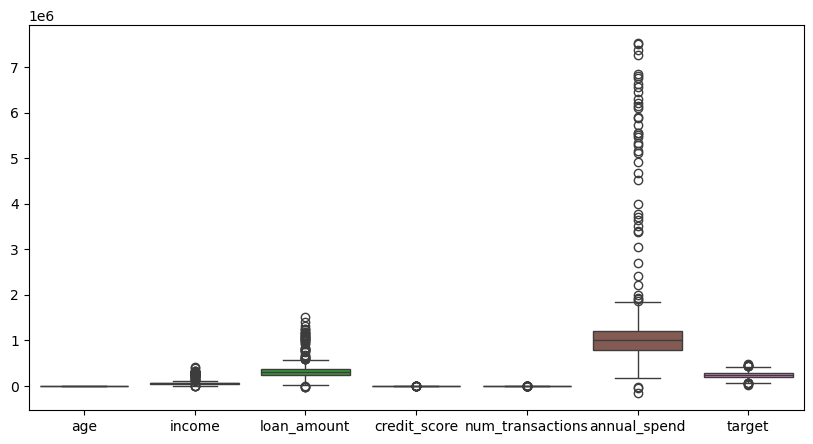

In [5]:
# box plot to check for outliers after capping
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

In [6]:
# check the city column value counts
df['date'].value_counts()

date
2020-01-01    1
2023-08-22    1
2023-09-04    1
2023-09-03    1
2023-09-02    1
             ..
2021-10-23    1
2021-10-22    1
2021-10-21    1
2021-10-20    1
2025-06-22    1
Name: count, Length: 2000, dtype: int64

In [7]:
# chcek the employment_type  column value counts
df['annual_spend'].value_counts()

annual_spend
6.904324e+05    1
5.951086e+05    1
6.936559e+05    1
8.052197e+05    1
1.318973e+06    1
               ..
6.279906e+05    1
1.351750e+06    1
1.012975e+06    1
1.036522e+06    1
1.456549e+06    1
Name: count, Length: 1920, dtype: int64

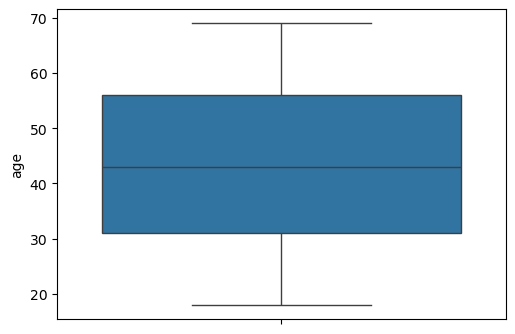

In [8]:
#plot the boxplot for all the columns to check the outlers
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10)) 
for i in range(len(df. columns)) :
 plt.subplot(3,3,1+1)
sns.boxplot(df[df.columns[1]])
plt.tight_layout()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
# STEP 1: Handle date columns
date_cols = [col for col in df.columns if col.startswith('date_')]

if len(date_cols) > 0:
    df['date'] = df[date_cols].idxmax(axis=1)
    df['date'] = df['date'].str.replace('date_', '')
    df['date'] = pd.to_datetime(df['date'])

    # Extract useful features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day

    # Drop original date columns
    df = df.drop(columns=date_cols + ['date'])

In [23]:
df = df.drop(columns=['annual_spend'])   # use your actual column name

In [31]:
# Fill missing values
X = X.fillna(X.mean(numeric_only=True))   # for numeric columns

In [32]:
X = X.fillna("Unknown")

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("task1_dataset.csv")

# Define X and y
X = df.drop('target', axis=1)
y = df['target']

# Handle missing values
X = X.fillna(X.mean(numeric_only=True))   # numeric
X = pd.get_dummies(X, drop_first=True)    # categorical

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\nKNN:")
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("R2:", r2_score(y_test, y_pred_knn))

Linear Regression:
MSE: 4239376261.7501836
R2: 0.06074352053983634

KNN:
MSE: 3002161770.900249
R2: 0.3348550065849706
